# Exploratory Data Analysis (EDA)

## 1. Carga y vista general

Cargamos el CSV consolidado generado en el notebook 02 y revisamos su estructura básica: dimensiones, tipos de datos y primeras filas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

# ── AJUSTA ESTA RUTA ──────────────────────────────────────────────
CSV_PATH = 'sweet_55_usuarios.csv'
# ─────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])

print(f'Filas:    {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'Usuarios: {df["user_id"].nunique()}')
print(f'\nTipos de datos:')
print(df.dtypes)
df.head(5)

Filas:    770
Columnas: 37
Usuarios: 55

Tipos de datos:
ECG_mean_heart_rate                       float64
ECG_sdnn                                  float64
ECG_rmssd                                 float64
ECG_LF                                    float64
ECG_HF                                    float64
ECG_LFHF                                  float64
('ECG_mean_heart_rate', 'raw0')           float64
ECG_QI_mean                               float64
mean_x                                    float64
mean_y                                    float64
mean_z                                    float64
std_x                                     float64
std_y                                     float64
std_z                                     float64
magnitude_xyz                             float64
GSR_mean                                  float64
GSR_std                                   float64
GSR_median                                float64
GSR_min                                   f

,ECG_mean_heart_rate,ECG_sdnn,ECG_rmssd,ECG_LF,ECG_HF,ECG_LFHF,"('ECG_mean_heart_rate', 'raw0')",ECG_QI_mean,mean_x,mean_y,...,user_id,timestamp,MAXIMUM_STRESS,PLEASURE,AROUSAL,DOMINANCE,ACTIVITY_list,CONSUMPTION_list,ACC_std_mean,stress_label
0,69.147348,94.253324,872.896392,0.001457,0.000761,2.609068,NaN,0.970375,-0.211074,-1.025849,...,user0091,2015-12-04 11:05:22,1.0,3.0,NaN,2.0,[2],[8],0.093661,S1
1,80.453756,50.559109,747.529235,0.000687,0.000138,5.217690,NaN,1.000000,-0.097653,-1.106464,...,user0091,2015-12-04 14:37:43,1.0,4.0,1.0,1.0,"[2, 4, 6]",[8],0.047923,S1
2,84.092332,59.158718,716.085356,0.000240,0.000128,1.945566,NaN,0.979992,0.846308,-0.590822,...,user0091,2015-12-04 20:57:59,1.0,4.0,1.0,1.0,[1],[2],0.091517,S1
3,94.257167,37.155836,637.785272,0.000176,0.000077,2.485655,NaN,0.966654,0.819179,-0.710465,...,user0091,2015-12-06 20:51:46,1.0,4.0,2.0,1.0,[1],[8],0.042688,S1
4,86.105870,57.869490,699.409036,0.000785,0.000230,3.428975,NaN,0.959984,-0.027007,-1.081829,...,user0091,2015-12-07 14:06:26,1.0,4.0,1.0,1.0,[2],[1],0.091870,S1


In [2]:
feature_cols = [
    'ECG_mean_heart_rate',  # frecuencia cardíaca media
    'ECG_sdnn',             # variabilidad total RR
    'ECG_rmssd',            # HRV corto plazo — baja con estrés
    'ECG_LF',               # actividad simpática
    'ECG_HF',               # actividad parasimpática
    'ECG_LFHF',             # ratio simpático/parasimpático
    'mean_x',               # acelerómetro eje X
    'mean_y',               # acelerómetro eje Y
    'mean_z',               # acelerómetro eje Z
    'GSR_mean',             # conductancia piel media
    'TEMP_mean',            # temperatura media
    'ACC_mag_mean',         # magnitud ACC cruda media
]

# Verificar cuáles existen realmente en el dataset
feature_cols = [c for c in feature_cols if c in df.columns]
print(f'Features disponibles ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  ✓ {c}')

esperadas = ['ECG_mean_heart_rate','ECG_sdnn','ECG_rmssd','ECG_LF',
             'ECG_HF','ECG_LFHF','mean_x','mean_y','mean_z',
             'GSR_mean','TEMP_mean','ACC_mag_mean']
faltantes = [c for c in esperadas if c not in df.columns]
if faltantes:
    print(f'\n⚠ No encontradas en el dataset: {faltantes}')

Features disponibles (12):
  ✓ ECG_mean_heart_rate
  ✓ ECG_sdnn
  ✓ ECG_rmssd
  ✓ ECG_LF
  ✓ ECG_HF
  ✓ ECG_LFHF
  ✓ mean_x
  ✓ mean_y
  ✓ mean_z
  ✓ GSR_mean
  ✓ TEMP_mean
  ✓ ACC_mag_mean


## 2. ¿Es balanceada la data?

Revisamos cuántas muestras hay por clase (S1/S2/S3). Un dataset desbalanceado puede sesgar los modelos hacia la clase mayoritaria, lo que requiere estrategias como `class_weight='balanced'` o técnicas de oversampling (SMOTE).

Distribución de clases:
  S1 (Sin estrés  ):  443 muestras (57.5%)
  S2 (Leve        ):  220 muestras (28.6%)
  S3 (Alto        ):  107 muestras (13.9%)


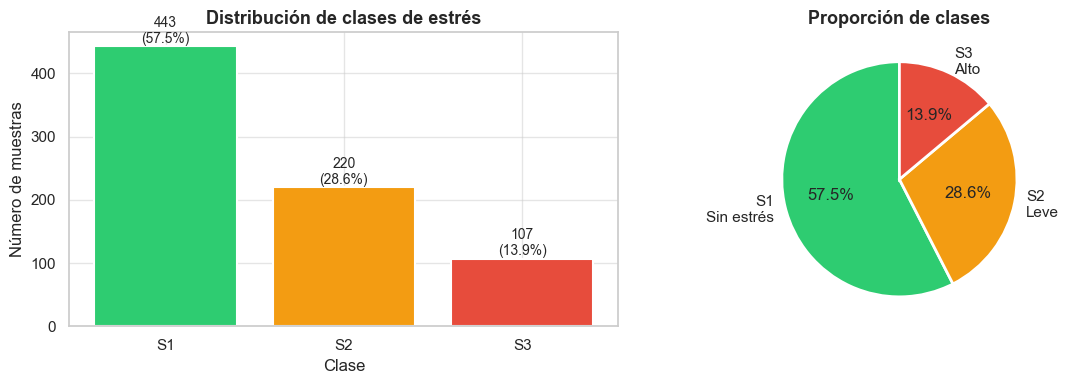


Ratio max/min clases: 4.14
⚠ Dataset DESBALANCEADO — usar class_weight="balanced" en los modelos


In [3]:
# Conteo y porcentaje por clase
dist = df['stress_label'].value_counts().reindex(['S1','S2','S3'])
pcts = dist / len(df) * 100

print('Distribución de clases:')
nombres = {'S1':'Sin estrés','S2':'Leve','S3':'Alto'}
for label, count in dist.items():
    print(f'  {label} ({nombres[label]:12}): {count:>4} muestras ({pcts[label]:.1f}%)')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colores = ['#2ecc71','#f39c12','#e74c3c']
axes[0].bar(dist.index, dist.values, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de clases de estrés', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de muestras')
for i, (label, val) in enumerate(dist.items()):
    axes[0].text(i, val + 5, f'{val}\n({pcts[label]:.1f}%)',
                 ha='center', fontsize=10)

# Pie
axes[1].pie(dist.values, labels=[f'{l}\n{nombres[l]}' for l in dist.index],
            colors=colores, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_01_distribucion_clases.png', bbox_inches='tight')
plt.show()

# Conclusión
ratio = dist.max() / dist.min()
print(f'\nRatio max/min clases: {ratio:.2f}')
if ratio > 2:
    print('⚠ Dataset DESBALANCEADO — usar class_weight="balanced" en los modelos')
else:
    print('✓ Dataset razonablemente balanceado')

In [4]:
# Distribución por usuario — verificar que no haya usuarios con solo 1 clase
dist_user = df.groupby(['user_id','stress_label']).size().unstack(fill_value=0)
print('Clases por usuario (primeros 10):')
print(dist_user.head(10))

# Usuarios con solo 1 clase (problemáticos para k-fold)
usuarios_1clase = dist_user[(dist_user == 0).sum(axis=1) >= 2].index.tolist()
if usuarios_1clase:
    print(f'\n⚠ Usuarios con solo 1 clase: {usuarios_1clase}')
    print('  Considerar excluirlos del entrenamiento')
else:
    print('\n✓ Todos los usuarios tienen al menos 2 clases')

Clases por usuario (primeros 10):
stress_label  S1  S2  S3
user_id                 
user0091       5   0   0
user0093      15   0   1
user0096      11   6   1
user0098       1   4   0
user0099       8  14   3
user0103       8   4   6
user0105       6   3   1
user0125      16   1   0
user0129       7   5   5
user0132       8   1   1

⚠ Usuarios con solo 1 clase: ['user0091', 'user0170', 'user0220', 'user1077']
  Considerar excluirlos del entrenamiento


## 3. ¿Está normalizada la data?

Las señales fisiológicas tienen escalas muy distintas — HR en bpm (~70), GSR en µS (~0-20), temperatura en °C (~30-36). Sin normalización, los modelos priorizan features con valores más grandes. Aplicamos z-score **por usuario** porque cada persona tiene su propia línea base fisiológica.

In [5]:
# Mostrar escalas originales de las features clave
features_clave = [c for c in ['ECG_mean_heart_rate','ECG_rmssd',
                               'GSR_mean','TEMP_median','ACC_std_mean']
                  if c in df.columns]

print('Estadísticos ANTES de normalizar:')
print(df[features_clave].describe().round(3))

Estadísticos ANTES de normalizar:
       ECG_mean_heart_rate  ECG_rmssd  GSR_mean  TEMP_median  ACC_std_mean
count              770.000    770.000   770.000      770.000       770.000
mean                72.153    856.709     1.503       30.891         0.059
std                 11.518    138.914     2.281        2.552         0.025
min                 41.732    481.202    -5.975       14.000         0.007
25%                 64.227    758.947     0.250       30.000         0.039
50%                 71.203    845.635     0.586       31.000         0.059
75%                 79.548    937.923     1.714       32.750         0.082
max                125.037   1440.868    17.013       38.000         0.100


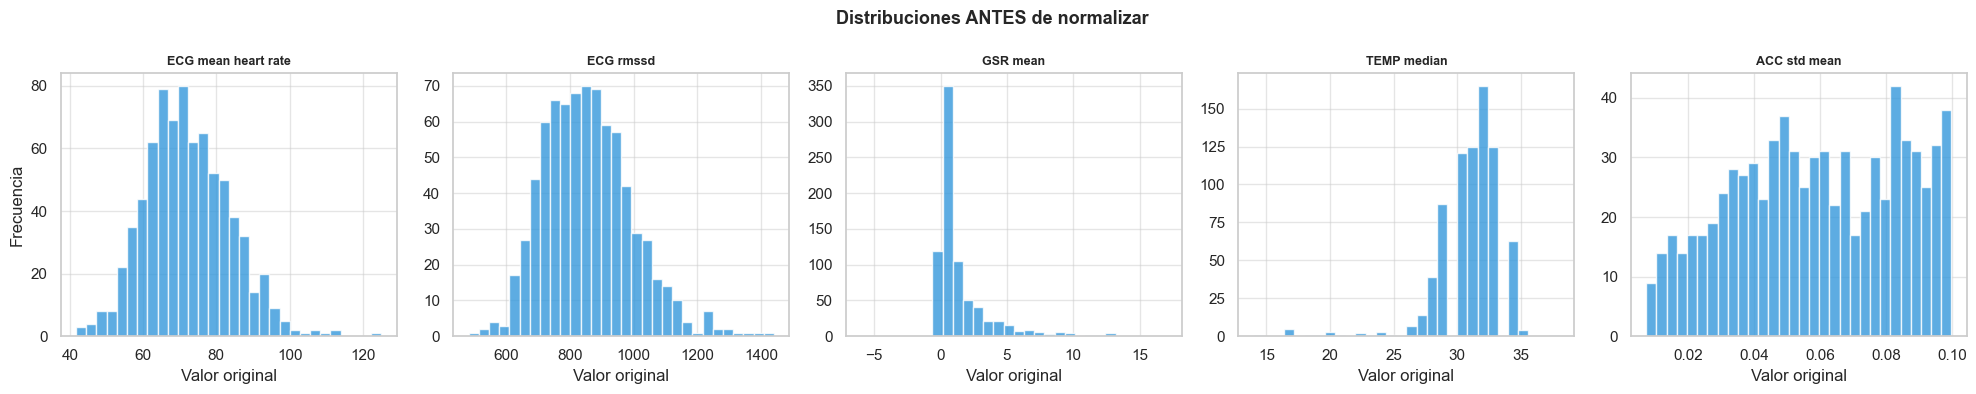

In [6]:
# Visualizar distribuciones ANTES de normalizar
n_feats = len(features_clave)
fig, axes = plt.subplots(1, n_feats, figsize=(4*n_feats, 4))
if n_feats == 1: axes = [axes]

for ax, col in zip(axes, features_clave):
    ax.hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor original')

axes[0].set_ylabel('Frecuencia')
fig.suptitle('Distribuciones ANTES de normalizar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_antes_normalizar.png', bbox_inches='tight')
plt.show()

In [7]:
# Z-score por usuario (cada persona es su propia referencia)
df_norm = df.copy()
for col in feature_cols:
    if col in df_norm.columns:
        df_norm[col] = df_norm.groupby('user_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )

print('Estadísticos DESPUÉS de normalizar (z-score por usuario):')
print(df_norm[features_clave].describe().round(3))

Estadísticos DESPUÉS de normalizar (z-score por usuario):
       ECG_mean_heart_rate  ECG_rmssd  GSR_mean  TEMP_median  ACC_std_mean
count              770.000    770.000   770.000      770.000       770.000
mean                 0.000     -0.000    -0.000       30.891         0.059
std                  0.964      0.964     0.964        2.552         0.025
min                 -2.245     -2.697    -2.736       14.000         0.007
25%                 -0.684     -0.673    -0.642       30.000         0.039
50%                 -0.098      0.017    -0.346       31.000         0.059
75%                  0.631      0.653     0.467       32.750         0.082
max                  3.114      2.505     4.540       38.000         0.100


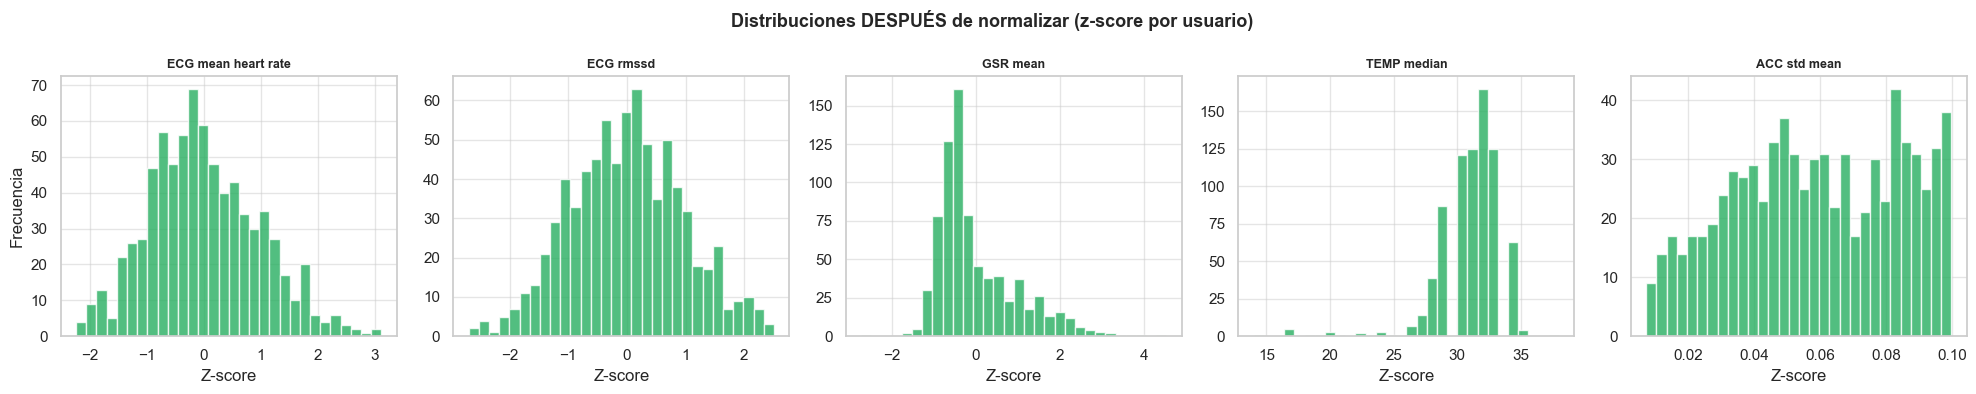

✓ Guardado: sweet_55_normalizado.csv


In [8]:
# Visualizar distribuciones DESPUÉS de normalizar
fig, axes = plt.subplots(1, n_feats, figsize=(4*n_feats, 4))
if n_feats == 1: axes = [axes]

for ax, col in zip(axes, features_clave):
    ax.hist(df_norm[col].dropna(), bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Z-score')

axes[0].set_ylabel('Frecuencia')
fig.suptitle('Distribuciones DESPUÉS de normalizar (z-score por usuario)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_despues_normalizar.png', bbox_inches='tight')
plt.show()

# Guardar versión normalizada para los siguientes notebooks
df_norm.to_csv('sweet_55_normalizado.csv', index=False)
print('✓ Guardado: sweet_55_normalizado.csv')

## 4. ¿Hay estacionalidad?

Las señales fisiológicas varían naturalmente a lo largo del día — HR es mayor durante el día y menor por la noche, temperatura y conductancia también tienen ritmos circadianos. Visualizamos la variación temporal de las señales clave agrupadas por hora del día.

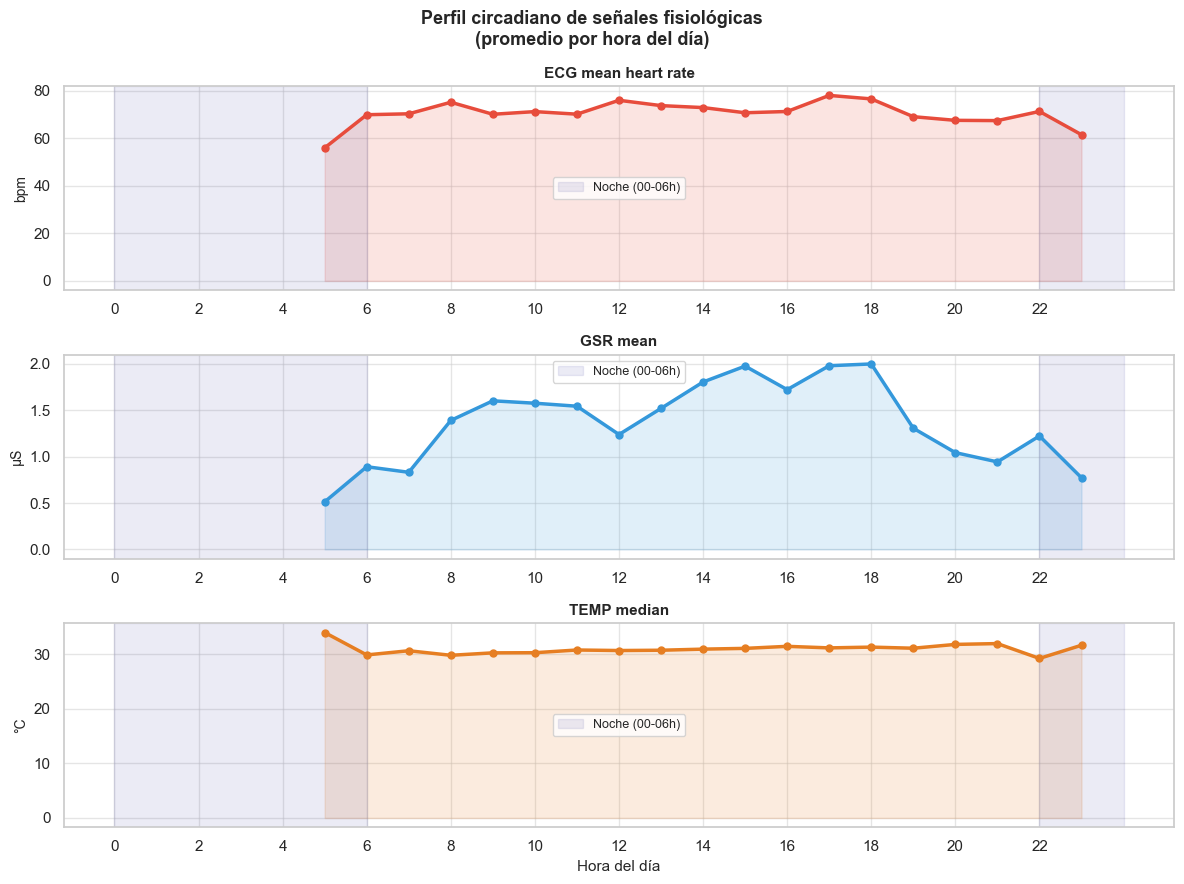

Interpretación:
  Si HR es menor en horas nocturnas (0-6h) → confirma ritmo circadiano
  Este patrón justifica incluir la hora como variable contextual


In [9]:
# Extraer hora del día desde el timestamp
df['hora'] = pd.to_datetime(df['timestamp']).dt.hour

# Agrupar por hora y calcular media de señales clave
señales_temporales = [c for c in ['ECG_mean_heart_rate','GSR_mean','TEMP_median']
                      if c in df.columns]

perfil_horario = df.groupby('hora')[señales_temporales].mean()

fig, axes = plt.subplots(len(señales_temporales), 1,
                          figsize=(12, 3*len(señales_temporales)))
if len(señales_temporales) == 1: axes = [axes]

colores_señal = ['#e74c3c','#3498db','#e67e22']
unidades      = {'ECG_mean_heart_rate':'bpm','GSR_mean':'µS','TEMP_median':'°C'}

for ax, col, color in zip(axes, señales_temporales, colores_señal):
    ax.plot(perfil_horario.index, perfil_horario[col],
            color=color, linewidth=2.5, marker='o', markersize=5)
    ax.fill_between(perfil_horario.index, perfil_horario[col],
                    alpha=0.15, color=color)
    ax.set_ylabel(f'{unidades.get(col,"")}', fontsize=10)
    ax.set_title(col.replace('_',' '), fontsize=11, fontweight='bold')
    ax.set_xticks(range(0,24,2))
    ax.axvspan(0, 6, alpha=0.08, color='navy', label='Noche (00-06h)')
    ax.axvspan(22, 24, alpha=0.08, color='navy')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Hora del día', fontsize=11)
fig.suptitle('Perfil circadiano de señales fisiológicas\n(promedio por hora del día)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_estacionalidad.png', bbox_inches='tight')
plt.show()

print('Interpretación:')
print('  Si HR es menor en horas nocturnas (0-6h) → confirma ritmo circadiano')
print('  Este patrón justifica incluir la hora como variable contextual')

## 5. ¿Se necesitan transformaciones no lineales? (Skewness)

Distribuciones muy asimétricas (skewness alto) pueden perjudicar modelos que asumen normalidad. Calculamos el skewness de cada feature y aplicamos transformación logarítmica donde sea necesario (skewness > 1 o < -1).

In [10]:
# Calcular skewness de todas las features
skewness = df[feature_cols].skew().sort_values(ascending=False)

print('Skewness por feature:')
for col, val in skewness.items():
    nivel = '⚠ ALTO' if abs(val) > 1 else ('~ moderado' if abs(val) > 0.5 else '✓ normal')
    print(f'  {col:35} {val:>7.3f}  {nivel}')

features_sesgadas = skewness[abs(skewness) > 1].index.tolist()
print(f'\nFeatures con skewness > 1: {features_sesgadas}')

Skewness por feature:
  ECG_LF                                5.240  ⚠ ALTO
  ECG_HF                                3.341  ⚠ ALTO
  GSR_mean                              2.828  ⚠ ALTO
  ECG_LFHF                              2.649  ⚠ ALTO
  mean_y                                2.454  ⚠ ALTO
  ECG_sdnn                              0.932  ~ moderado
  ECG_rmssd                             0.626  ~ moderado
  ECG_mean_heart_rate                   0.426  ✓ normal
  ACC_mag_mean                          0.032  ✓ normal
  mean_z                                0.016  ✓ normal
  mean_x                               -0.409  ✓ normal
  TEMP_mean                            -2.313  ⚠ ALTO

Features con skewness > 1: ['ECG_LF', 'ECG_HF', 'GSR_mean', 'ECG_LFHF', 'mean_y', 'TEMP_mean']


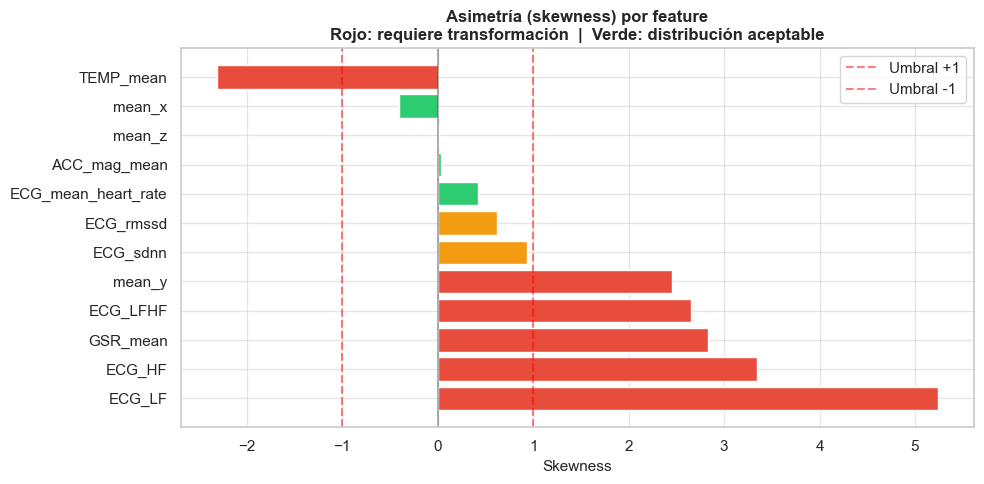

In [11]:
# Visualizar skewness
fig, ax = plt.subplots(figsize=(10, 5))
colores_skew = ['#e74c3c' if abs(v) > 1 else '#f39c12' if abs(v) > 0.5
                else '#2ecc71' for v in skewness.values]
bars = ax.barh(skewness.index, skewness.values, color=colores_skew, edgecolor='white')
ax.axvline(x=1,  color='red',    linestyle='--', alpha=0.5, label='Umbral +1')
ax.axvline(x=-1, color='red',    linestyle='--', alpha=0.5, label='Umbral -1')
ax.axvline(x=0,  color='black',  linestyle='-',  alpha=0.3)
ax.set_xlabel('Skewness', fontsize=11)
ax.set_title('Asimetría (skewness) por feature\nRojo: requiere transformación  |  Verde: distribución aceptable',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_skewness.png', bbox_inches='tight')
plt.show()

In [12]:
# Aplicar log1p a features con skewness alto y positivo
# (log1p = log(x+1), funciona con valores >= 0)
df_norm_log = df_norm.copy()
transformadas = []

for col in features_sesgadas:
    if col in df_norm_log.columns:
        if df_norm_log[col].min() >= 0 and skewness[col] > 1:
            df_norm_log[col] = np.log1p(df_norm_log[col])
            transformadas.append(col)

if transformadas:
    print(f'Features transformadas con log1p: {transformadas}')
    print(f'Skewness después de transformar:')
    print(df_norm_log[transformadas].skew().round(3))
else:
    print('No se requirieron transformaciones logarítmicas')

No se requirieron transformaciones logarítmicas


## 6. Boxplots por clase de estrés

Comparamos la distribución de cada feature entre las clases S1, S2 y S3. Si los boxplots se separan visualmente, la feature es útil para discriminar niveles de estrés — esto valida la selección de features antes de pasarlas a TINTOlib.

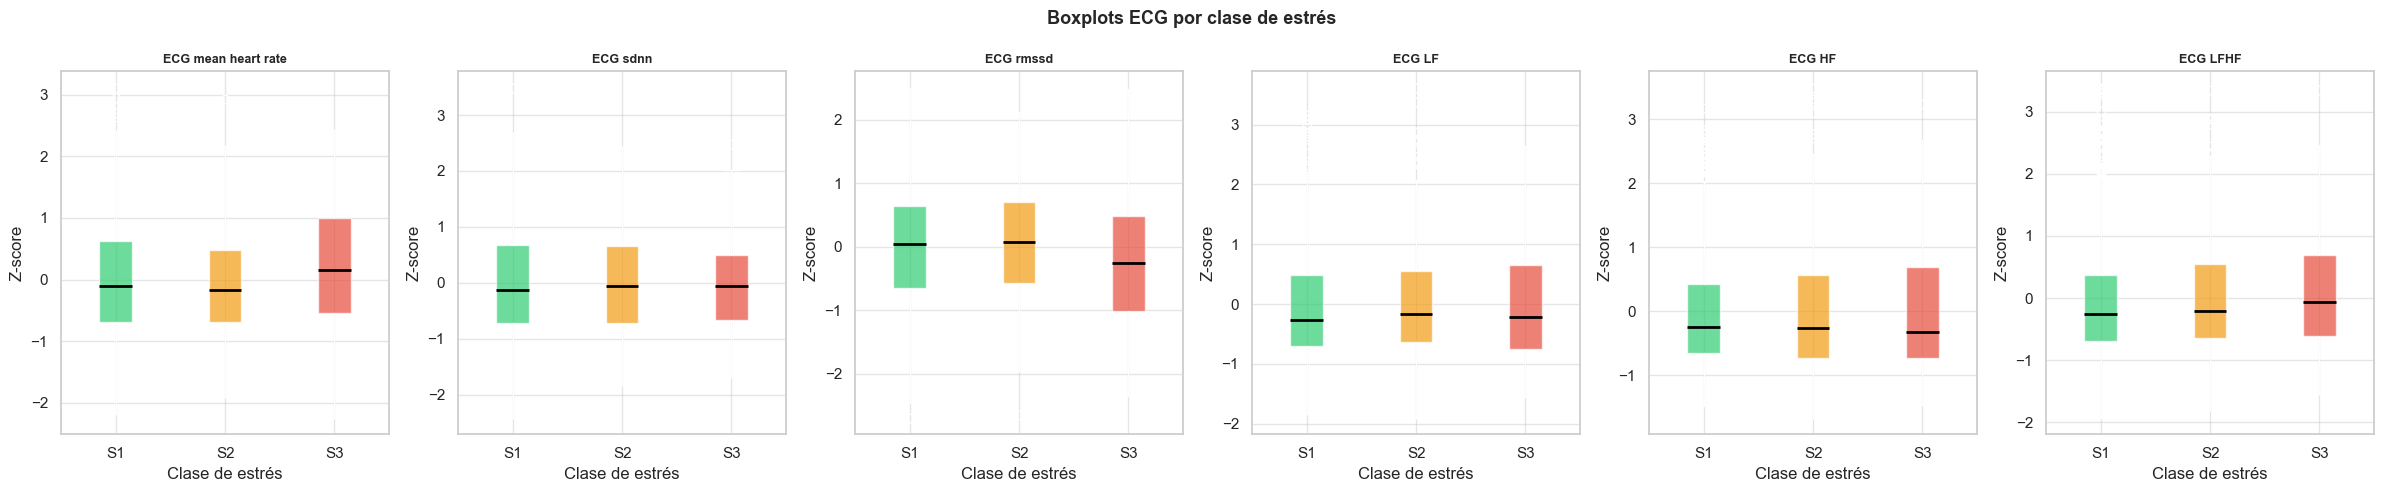

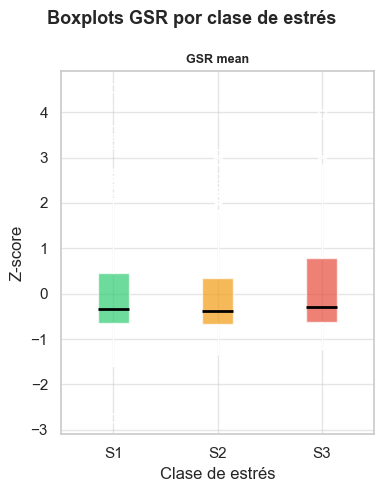

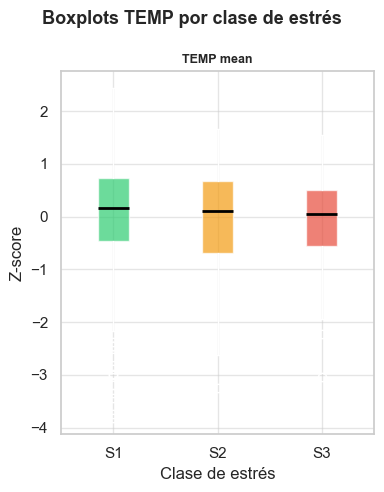

In [13]:
# Boxplots de features ECG por clase
ecg_cols  = [c for c in feature_cols if 'ECG' in str(c) and 'QI' not in str(c)
                                      and 'raw' not in str(c)]
gsr_cols  = [c for c in feature_cols if 'GSR' in str(c)]
temp_cols = [c for c in feature_cols if 'TEMP' in str(c)]

# Usar datos normalizados para comparación justa
df_plot = df_norm[feature_cols + ['stress_label']].copy()
orden   = ['S1','S2','S3']
colores = {'S1':'#2ecc71','S2':'#f39c12','S3':'#e74c3c'}

def plot_boxplots(cols, titulo, filename):
    if len(cols) == 0: return
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        data_plot = [df_plot[df_plot['stress_label']==l][col].dropna()
                     for l in orden]
        bp = ax.boxplot(data_plot, labels=orden, patch_artist=True,
                        medianprops={'color':'black','linewidth':2})
        for patch, label in zip(bp['boxes'], orden):
            patch.set_facecolor(colores[label])
            patch.set_alpha(0.7)
        ax.set_title(col.replace('_',' '), fontsize=9, fontweight='bold')
        ax.set_xlabel('Clase de estrés')
        ax.set_ylabel('Z-score')
    fig.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

plot_boxplots(ecg_cols,  'Boxplots ECG por clase de estrés',  'eda_06_boxplot_ecg.png')
plot_boxplots(gsr_cols,  'Boxplots GSR por clase de estrés',  'eda_07_boxplot_gsr.png')
plot_boxplots(temp_cols, 'Boxplots TEMP por clase de estrés', 'eda_08_boxplot_temp.png')

## 7. Matriz de correlación

Identificamos features altamente correlacionadas (r > 0.8) que aportan información redundante. Features redundantes pueden eliminarse antes de pasar a TINTOlib para reducir ruido y mejorar la imagen generada.

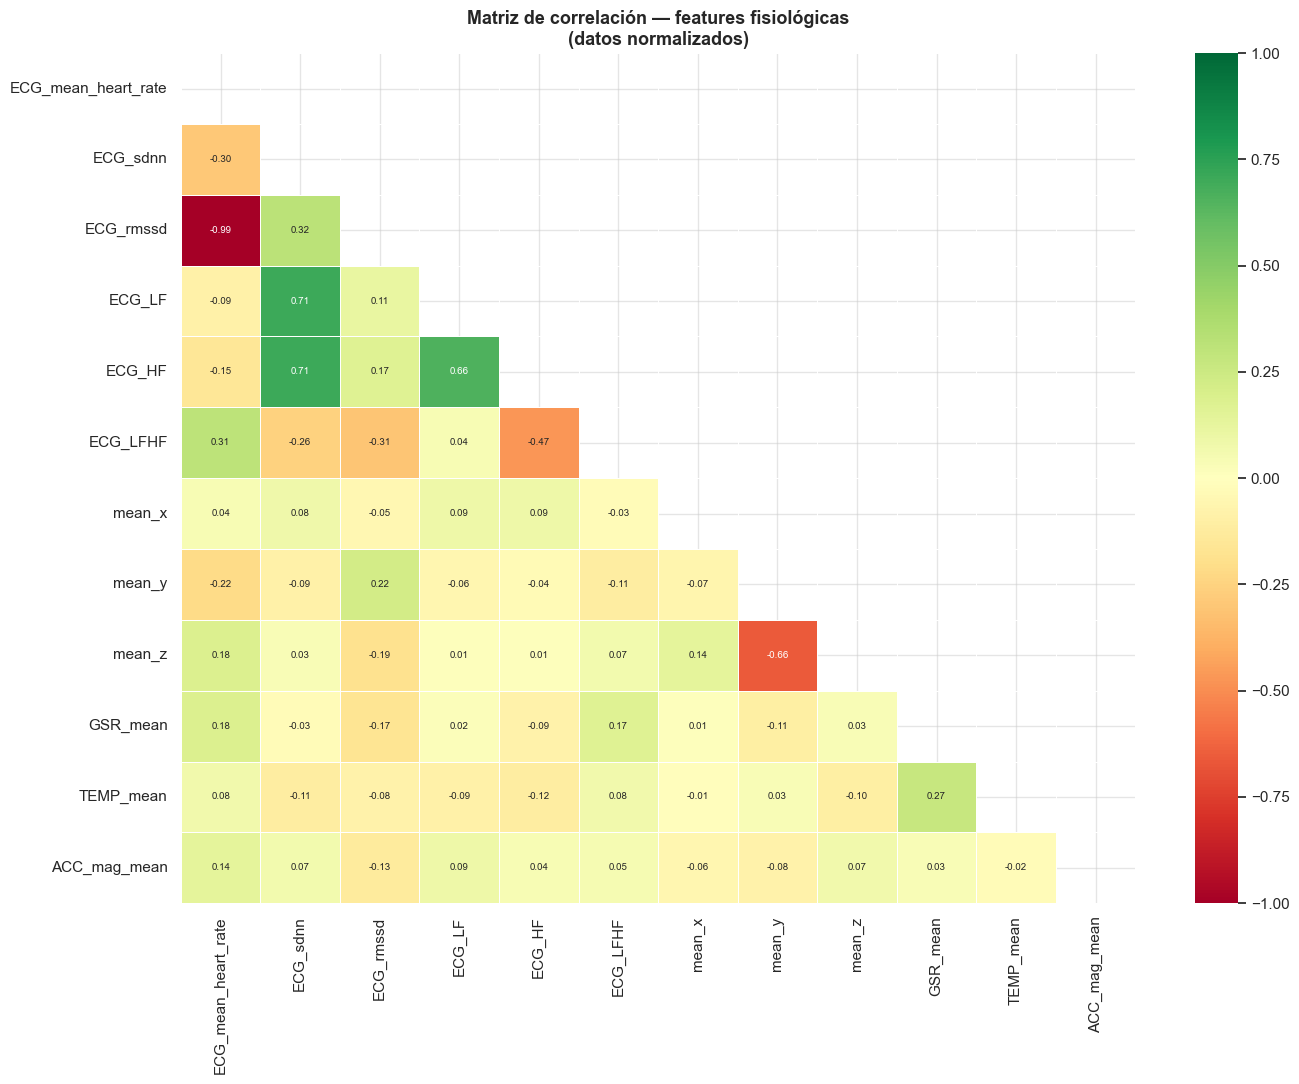

Pares con correlación > 0.8 (posible redundancia):
  ECG_mean_heart_rate            ↔ ECG_rmssd                     : -0.993


In [14]:
# Matriz de correlación sobre datos normalizados
cols_corr = [c for c in feature_cols if c in df_norm.columns]
corr_matrix = df_norm[cols_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size':7})
ax.set_title('Matriz de correlación — features fisiológicas\n(datos normalizados)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_09_correlacion.png', bbox_inches='tight')
plt.show()

# Identificar pares altamente correlacionados
print('Pares con correlación > 0.8 (posible redundancia):')
alta_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i,j]
        if abs(val) > 0.8:
            alta_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
            print(f'  {corr_matrix.columns[i]:30} ↔ {corr_matrix.columns[j]:30}: {val:.3f}')

if not alta_corr:
    print('  ✓ No hay pares con correlación > 0.8')

## 8. Visualización t-SNE

t-SNE reduce las features fisiológicas a 2 dimensiones para visualizar si las clases S1/S2/S3 forman grupos separables. Si los colores se agrupan, los modelos ML tendrán más fácil discriminar entre niveles de estrés. Esta visualización se repetirá más adelante con los embeddings de la CNN para comparar.

In [15]:
# Preparar datos para t-SNE (eliminar NaN)
cols_tsne = [c for c in feature_cols if c in df_norm.columns]
df_tsne   = df_norm[cols_tsne + ['stress_label']].dropna()

X_tsne = df_tsne[cols_tsne].values
y_tsne = df_tsne['stress_label'].values

print(f'Muestras para t-SNE: {len(X_tsne)}')
print(f'Features usadas:     {len(cols_tsne)}')

# Perplexity debe ser menor que n_samples
# Regla general: entre 5 y 50, pero nunca >= n_samples
perplexity = min(30, len(X_tsne) - 1)
print(f'Perplexity usada:    {perplexity}')

# Ejecutar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity,
            n_iter=1000, learning_rate='auto', init='pca')
X_2d = tsne.fit_transform(X_tsne)
print('✓ t-SNE completado')

Muestras para t-SNE: 770
Features usadas:     12
Perplexity usada:    30
✓ t-SNE completado


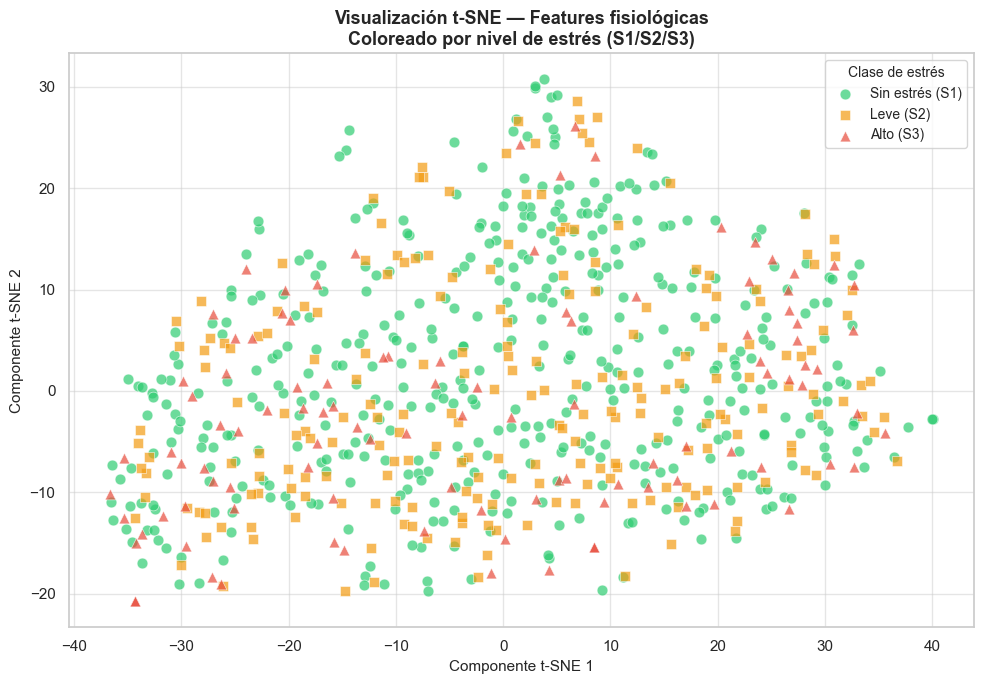

Interpretación:
  Grupos claramente separados → features discriminativas, modelos ML funcionarán bien
  Grupos mezclados → el problema es difícil, se espera menor accuracy
  Comparar esta visualización con t-SNE de embeddings CNN (notebook siguiente)


In [16]:
# Visualizar t-SNE
fig, ax = plt.subplots(figsize=(10, 7))

colores_tsne  = {'S1':'#2ecc71','S2':'#f39c12','S3':'#e74c3c'}
marcadores    = {'S1':'o','S2':'s','S3':'^'}
nombres_label = {'S1':'Sin estrés (S1)','S2':'Leve (S2)','S3':'Alto (S3)'}

for label in ['S1','S2','S3']:
    mask = y_tsne == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colores_tsne[label],
               marker=marcadores[label],
               label=nombres_label[label],
               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

ax.set_title('Visualización t-SNE — Features fisiológicas\nColoreado por nivel de estrés (S1/S2/S3)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente t-SNE 1', fontsize=11)
ax.set_ylabel('Componente t-SNE 2', fontsize=11)
ax.legend(title='Clase de estrés', fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.savefig('eda_10_tsne.png', bbox_inches='tight')
plt.show()


## 9. Resumen del EDA

In [17]:
print('=' * 55)
print('RESUMEN EDA — SWEET Dataset (55 usuarios)')
print('=' * 55)

print(f"""
1. BALANCE DE CLASES
   S1 (sin estrés): {(df['stress_label']=='S1').sum()} muestras ({(df['stress_label']=='S1').mean()*100:.1f}%)
   S2 (leve):       {(df['stress_label']=='S2').sum()} muestras ({(df['stress_label']=='S2').mean()*100:.1f}%)
   S3 (alto):       {(df['stress_label']=='S3').sum()} muestras ({(df['stress_label']=='S3').mean()*100:.1f}%)
   → Usar class_weight='balanced' en los modelos ML

2. NORMALIZACIÓN
   → Aplicada z-score por usuario
   → Guardada en: sweet_55_normalizado.csv

3. ESTACIONALIDAD
   → Ritmo circadiano visible en HR, GSR y temperatura
   → La hora del día es una variable contextual relevante

4. SKEWNESS
   → Features con skewness > 1: {features_sesgadas}
   → Transformación log1p aplicada donde correspondía

5. CORRELACIONES
   → Pares altamente correlacionados (>0.8): {len(alta_corr)}


RESUMEN EDA — SWEET Dataset (55 usuarios)

1. BALANCE DE CLASES
   S1 (sin estrés): 443 muestras (57.5%)
   S2 (leve):       220 muestras (28.6%)
   S3 (alto):       107 muestras (13.9%)
   → Usar class_weight='balanced' en los modelos ML

2. NORMALIZACIÓN
   → Aplicada z-score por usuario
   → Guardada en: sweet_55_normalizado.csv

3. ESTACIONALIDAD
   → Ritmo circadiano visible en HR, GSR y temperatura
   → La hora del día es una variable contextual relevante

4. SKEWNESS
   → Features con skewness > 1: ['ECG_LF', 'ECG_HF', 'GSR_mean', 'ECG_LFHF', 'mean_y', 'TEMP_mean']
   → Transformación log1p aplicada donde correspondía

5. CORRELACIONES
   → Pares altamente correlacionados (>0.8): 1

SIGUIENTE PASO → 04_TINTOlib.ipynb
   Convertir tabla normalizada a imágenes para CNN

